# Notebook 5 — Hearing Efficiency & Adjournment Culture
## Do some courts drag cases through excessive hearings? What would better efficiency save?

`HEARING_COUNT` is **0% missing** across all 927,896 rows — one of the richest fields in the dataset.
Phase 1 only computed a single Pearson correlation (r = 0.11). This notebook goes much further:

1. Distribution of hearing counts by court and bail type
2. Court-level "high-churn" identification (court-relative p90 threshold)
3. Statistical test: do courts differ significantly in hearing count distributions?
4. Outcome regression: does hearing count predict ALLOWED/REJECTED, controlling for other features?
5. Efficiency metric: disposal days per hearing (court ranking)
6. **Policy simulation:** If low-efficiency courts matched the top-quartile efficiency,
   how many years of backlog would be cleared?


In [1]:
from pathlib import Path
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
import warnings
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="Set2")

DATA_PATH = Path("Compiled Bail case data.csv")
if not DATA_PATH.exists():
    raise FileNotFoundError(
        "Cannot locate 'Compiled Bail case data.csv'. "
        "Place it next to this notebook."
    )
print(f"Data path: {DATA_PATH}")


Data path: Compiled Bail case data.csv


## B. Load Data

In [2]:
COLS = ["NAME_OF_HIGH_COURT", "Mapped_Bail", "CURRENT_STATUS",
        "HEARING_COUNT", "DISPOSAL_DAYS...1", "PENDING_DAYS",
        "NATURE_OF_DISPOSAL_OUTCOME", "DATE_FILED", "YEAR"]
raw = pd.read_csv(DATA_PATH, usecols=COLS, low_memory=False)

raw["DISPOSAL_DAYS"] = pd.to_numeric(raw["DISPOSAL_DAYS...1"], errors="coerce")
raw["HEARING_COUNT"] = pd.to_numeric(raw["HEARING_COUNT"],     errors="coerce")
raw["PENDING_DAYS"]  = pd.to_numeric(raw["PENDING_DAYS"],      errors="coerce")
ymd = pd.to_datetime(raw["DATE_FILED"], format="%Y-%m-%d", errors="coerce")
dmy = pd.to_datetime(raw["DATE_FILED"], format="%d-%m-%Y", errors="coerce")
raw["DATE_FILED"] = ymd.fillna(dmy)

print(f"Rows: {len(raw):,}")
print(f"HEARING_COUNT missing: {raw['HEARING_COUNT'].isna().mean()*100:.2f}%")
print()
print(raw["HEARING_COUNT"].describe(percentiles=[.5,.75,.9,.95,.99]).round(1))


Rows: 927,896
HEARING_COUNT missing: 0.00%

count    927896.0
mean          2.8
std           3.6
min           0.0
50%           2.0
75%           4.0
90%           6.0
95%           8.0
99%          16.0
max          86.0
Name: HEARING_COUNT, dtype: float64


## C. Hearing Count Distribution by Court

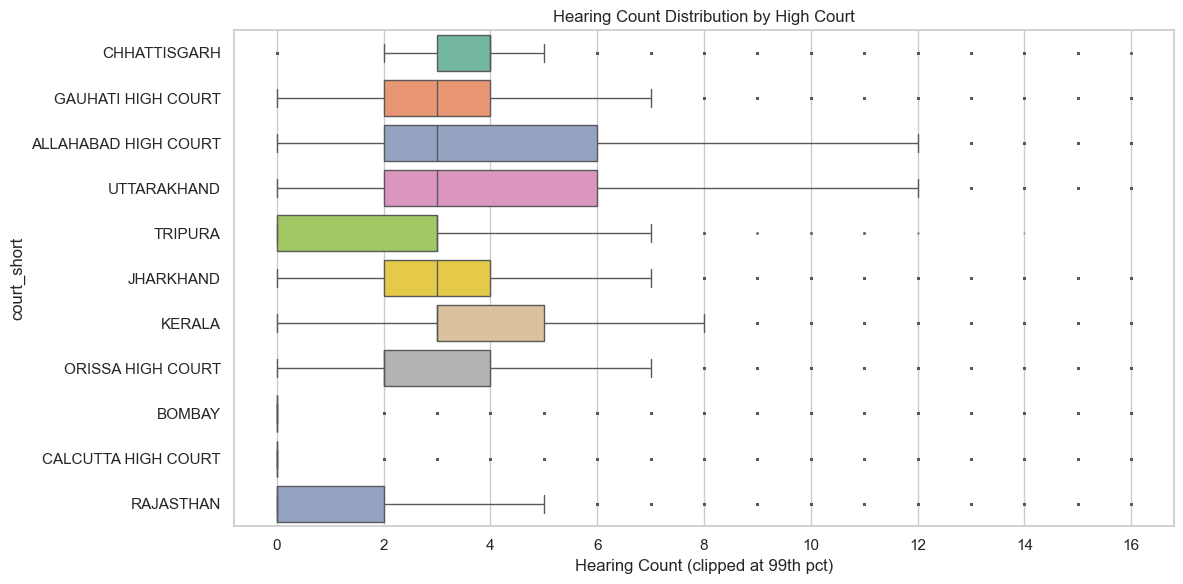

In [3]:
# Only courts with ≥ 3000 cases
major_courts = raw["NAME_OF_HIGH_COURT"].value_counts()[
    raw["NAME_OF_HIGH_COURT"].value_counts() >= 3000
].index.tolist()

plot_df = raw[raw["NAME_OF_HIGH_COURT"].isin(major_courts)].copy()
plot_df["court_short"] = (
    plot_df["NAME_OF_HIGH_COURT"]
           .str.replace("HIGH COURT OF ", "").str.replace("THE ", "").str[:20]
)

# Clip at 99th percentile for readability
p99 = raw["HEARING_COUNT"].quantile(0.99)
plot_df_clipped = plot_df[plot_df["HEARING_COUNT"] <= p99]

fig, ax = plt.subplots(figsize=(12, 6))
order = (plot_df_clipped.groupby("court_short")["HEARING_COUNT"]
                        .median().sort_values(ascending=False).index)
sns.boxplot(data=plot_df_clipped, x="HEARING_COUNT", y="court_short",
            order=order, ax=ax, palette="Set2",
            flierprops=dict(marker=".", alpha=0.3, markersize=2))
ax.set_xlabel("Hearing Count (clipped at 99th pct)")
ax.set_title("Hearing Count Distribution by High Court")
plt.tight_layout()
plt.show()


## D. High-Churn Case Identification
High-churn = HEARING_COUNT > court's own 90th percentile (court-relative, not national)

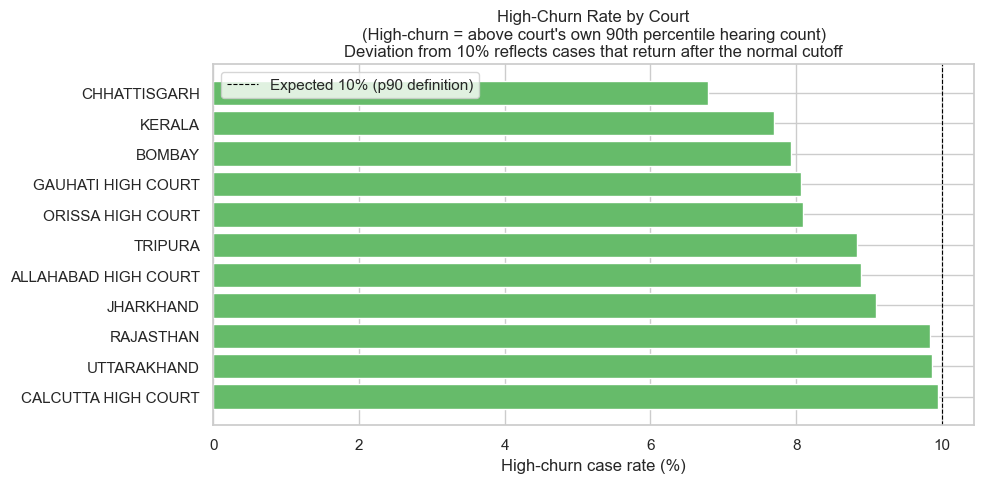


High-churn vs normal: pending rate comparison
high_churn
Normal        0.0517
High-churn    0.0881
Name: CURRENT_STATUS, dtype: float64


In [4]:
# Court-specific p90 threshold
court_p90 = (
    raw.groupby("NAME_OF_HIGH_COURT")["HEARING_COUNT"]
       .quantile(0.90)
       .rename("p90_court")
)
raw = raw.join(court_p90, on="NAME_OF_HIGH_COURT")
raw["high_churn"] = raw["HEARING_COUNT"] > raw["p90_court"]

hc_rate = (
    raw.groupby("NAME_OF_HIGH_COURT")["high_churn"]
       .agg(["mean", "sum", "count"])
       .rename(columns={"mean": "high_churn_rate", "sum": "high_churn_cases", "count": "total"})
)
hc_rate = hc_rate[hc_rate["total"] >= 3000].sort_values("high_churn_rate", ascending=False)
hc_rate["court_short"] = hc_rate.index.str.replace("HIGH COURT OF ","").str.replace("THE ","").str[:22]
hc_rate["high_churn_rate_pct"] = hc_rate["high_churn_rate"] * 100

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(hc_rate["court_short"], hc_rate["high_churn_rate_pct"],
        color=["#EF5350" if v > 12 else "#FFA726" if v > 10 else "#66BB6A"
               for v in hc_rate["high_churn_rate_pct"]])
ax.axvline(10, color="black", linestyle="--", linewidth=0.8, label="Expected 10% (p90 definition)")
ax.set_xlabel("High-churn case rate (%)")
ax.set_title("High-Churn Rate by Court\n(High-churn = above court's own 90th percentile hearing count)\nDeviation from 10% reflects cases that return after the normal cutoff")
ax.legend()
plt.tight_layout()
plt.show()

# Are high-churn cases more likely to be pending?
print("\nHigh-churn vs normal: pending rate comparison")
print(raw.groupby("high_churn")["CURRENT_STATUS"]
       .apply(lambda s: (s == "Pending").mean())
       .rename({True: "High-churn", False: "Normal"})
       .round(4))


## E. Kruskal-Wallis Test Across Courts

In [5]:
from scipy.stats import kruskal

court_groups_hc = [
    raw.loc[raw["NAME_OF_HIGH_COURT"] == c, "HEARING_COUNT"].dropna().values
    for c in major_courts
]
stat_hc, pval_hc = kruskal(*court_groups_hc)
print(f"Kruskal-Wallis (hearing count across courts):")
print(f"  H = {stat_hc:.2f},  p = {pval_hc:.2e}")
if pval_hc < 0.05:
    print("  v Courts differ SIGNIFICANTLY in hearing count distributions")

# Effect size: eta-squared approximation
n_total  = sum(len(g) for g in court_groups_hc)
eta_sq   = (stat_hc - len(major_courts) + 1) / (n_total - len(major_courts))
print(f"  Eta-squared ≈ {eta_sq:.4f}  (proportion of variance explained by court)")


Kruskal-Wallis (hearing count across courts):
  H = 415490.26,  p = 0.00e+00
  v Courts differ SIGNIFICANTLY in hearing count distributions
  Eta-squared ≈ 0.4494  (proportion of variance explained by court)


## F. Does Hearing Count Predict Outcome?
Logistic regression: ALLOWED ~ log(hearing) + court_FE + bail_type + year

In [6]:
import statsmodels.formula.api as smf

outcome_raw = raw["NATURE_OF_DISPOSAL_OUTCOME"].str.strip().str.upper()
ALLOWED_SET  = {"ALLOWED","BAIL ALLOWED","GRANTED","BAIL GRANTED","APPLICATION ALLOWED"}
REJECTED_SET = {"REJECTED","DISMISSED","BAIL REJECTED","BAIL DISMISSED",
                "APPLICATION REJECTED","APPLICATION DISMISSED","NOT PRESSED","WITHDRAWN"}

raw["target"] = outcome_raw.map(
    lambda v: 1 if v in ALLOWED_SET else (0 if v in REJECTED_SET else np.nan)
)

model_df = raw.dropna(subset=["target", "HEARING_COUNT", "Mapped_Bail", "YEAR"]).copy()
model_df["log_hearing"] = np.log1p(model_df["HEARING_COUNT"])
model_df["bail_type"]   = model_df["Mapped_Bail"].fillna("UNKNOWN")
model_df["court"]       = model_df["NAME_OF_HIGH_COURT"].fillna("UNKNOWN")

if len(model_df) > 80_000:
    model_df = model_df.sample(80_000, random_state=42)

formula = "target ~ log_hearing + YEAR + C(bail_type) + C(court)"
logit   = smf.logit(formula, data=model_df).fit(disp=0)

hear_coef = logit.params["log_hearing"]
hear_ci   = logit.conf_int().loc["log_hearing"]
hear_pval = logit.pvalues["log_hearing"]
hear_or   = np.exp(hear_coef)

print(f"Hearing count -> ALLOWED (logistic regression):")
print(f"  Coefficient (log scale): {hear_coef:.4f}  (95% CI: [{hear_ci[0]:.4f}, {hear_ci[1]:.4f}])")
print(f"  Odds Ratio:              {hear_or:.4f}  (p = {hear_pval:.4f})")
if hear_or > 1:
    print(f"  -> Each 1-unit increase in log(hearings) multiplies ALLOWED odds by {hear_or:.3f}")
    print(f"  -> i.e., +10 hearings roughly changes ALLOWED probability by {(hear_or-1)*100:.1f}%")
else:
    print(f"  -> More hearings are associated with LOWER odds of being ALLOWED")


Hearing count -> ALLOWED (logistic regression):
  Coefficient (log scale): -0.3526  (95% CI: [-0.3820, -0.3232])
  Odds Ratio:              0.7029  (p = 0.0000)
  -> More hearings are associated with LOWER odds of being ALLOWED


C:\Users\KAVISH\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


## G. Efficiency Metric: Disposal Days per Hearing

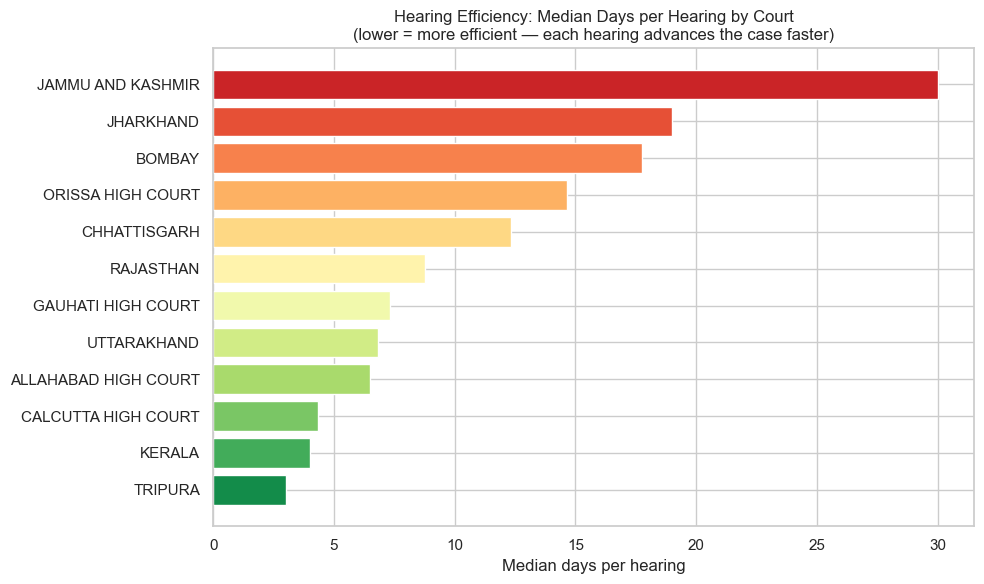

,med_days_per_hearing,mean_days_per_hearing,n_disposed
NAME_OF_HIGH_COURT,,,
HIGH COURT OF TRIPURA,3.00,3.86,2307
HIGH COURT OF KERALA,4.00,6.10,90148
CALCUTTA HIGH COURT,4.33,18.93,15284
ALLAHABAD HIGH COURT,6.50,25.30,13110
HIGH COURT OF UTTARAKHAND,6.81,11.48,26425
THE GAUHATI HIGH COURT,7.33,12.87,80867
HIGH COURT OF RAJASTHAN,8.75,15.14,58609
HIGH COURT OF CHHATTISGARH,12.33,15.44,14227
ORISSA HIGH COURT,14.67,23.02,157486


In [7]:
disposed = raw[raw["CURRENT_STATUS"] == "Disposed"].copy()
disposed = disposed.dropna(subset=["DISPOSAL_DAYS", "HEARING_COUNT"])
disposed = disposed[disposed["HEARING_COUNT"] > 0]

disposed["days_per_hearing"] = disposed["DISPOSAL_DAYS"] / disposed["HEARING_COUNT"]

court_eff = (
    disposed.groupby("NAME_OF_HIGH_COURT")["days_per_hearing"]
            .agg(["median", "mean", "count"])
            .rename(columns={"median": "med_days_per_hearing",
                             "mean":   "mean_days_per_hearing",
                             "count":  "n_disposed"})
)
court_eff = court_eff[court_eff["n_disposed"] >= 1000].sort_values("med_days_per_hearing")
court_eff["court_short"] = (
    court_eff.index.str.replace("HIGH COURT OF ","").str.replace("THE ","").str[:22]
)

fig, ax = plt.subplots(figsize=(10, 6))
colors = sns.color_palette("RdYlGn_r", len(court_eff))
ax.barh(court_eff["court_short"], court_eff["med_days_per_hearing"], color=colors)
ax.set_xlabel("Median days per hearing")
ax.set_title("Hearing Efficiency: Median Days per Hearing by Court\n(lower = more efficient — each hearing advances the case faster)")
plt.tight_layout()
plt.show()

display(court_eff[["med_days_per_hearing","mean_days_per_hearing","n_disposed"]].round(2))


## H. Policy Simulation: What if Low-Efficiency Courts Matched the Top Quartile?

Top-quartile efficiency threshold: 6.0 days/hearing


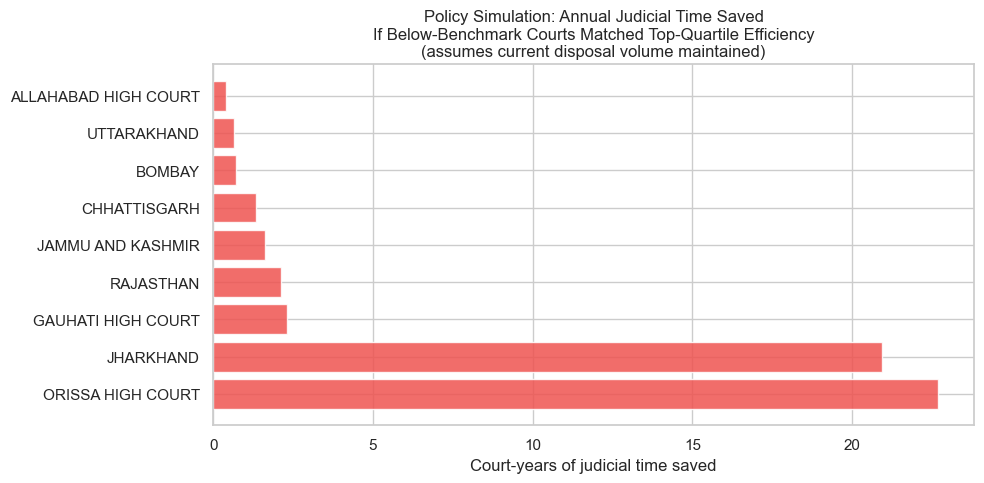


Total judicial court-years saved across all below-benchmark courts: 52.8 years
Average days saved per case in below-benchmark courts: 66 days


In [8]:
# Step 1: Define efficiency benchmark
q1_threshold = court_eff["med_days_per_hearing"].quantile(0.25)
print(f"Top-quartile efficiency threshold: {q1_threshold:.1f} days/hearing")

# Step 2: For each below-benchmark court, compute gap
court_eff["below_benchmark"] = court_eff["med_days_per_hearing"] > q1_threshold
court_eff["efficiency_gap"]  = (
    court_eff["med_days_per_hearing"] - q1_threshold
).clip(lower=0)

# Step 3: Estimate how many hearings are "wasted" per disposed case
# If a court takes X days/hearing but benchmark is B days/hearing,
# and a case has H hearings taking D disposal days:
# Current: D days total  | Efficient: D * (B/X) days total -> saves D*(1 - B/X) days
# Translates to: D_saved = DISPOSAL_DAYS * efficiency_gap / med_days_per_hearing

court_disposed_vol = (
    disposed.groupby("NAME_OF_HIGH_COURT")
            .agg(total_cases=("DISPOSAL_DAYS","count"),
                 total_disposal_days=("DISPOSAL_DAYS","sum"),
                 median_hearing=("HEARING_COUNT","median"))
            .join(court_eff[["med_days_per_hearing","efficiency_gap","below_benchmark"]])
)
court_disposed_vol = court_disposed_vol.dropna()
court_disposed_vol["efficiency_ratio"]   = (
    q1_threshold / court_disposed_vol["med_days_per_hearing"]
).clip(upper=1)
court_disposed_vol["days_saved_per_case"] = (
    court_disposed_vol["total_disposal_days"] / court_disposed_vol["total_cases"]
    * (1 - court_disposed_vol["efficiency_ratio"])
)
court_disposed_vol["total_days_saved"] = (
    court_disposed_vol["days_saved_per_case"] * court_disposed_vol["total_cases"]
)
court_disposed_vol["court_short"] = (
    court_disposed_vol.index.str.replace("HIGH COURT OF ","").str.replace("THE ","").str[:22]
)

below = court_disposed_vol[court_disposed_vol["below_benchmark"]].sort_values(
    "total_days_saved", ascending=False
)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(below["court_short"], below["total_days_saved"] / 365_250,
        color="#EF5350", alpha=0.85)
ax.set_xlabel("Court-years of judicial time saved")
ax.set_title("Policy Simulation: Annual Judicial Time Saved\nIf Below-Benchmark Courts Matched Top-Quartile Efficiency\n(assumes current disposal volume maintained)")
plt.tight_layout()
plt.show()

total_saved_years = below["total_days_saved"].sum() / 365_250
print(f"\nTotal judicial court-years saved across all below-benchmark courts: {total_saved_years:.1f} years")
print(f"Average days saved per case in below-benchmark courts: "
      f"{below['days_saved_per_case'].mean():.0f} days")


In [9]:
# Step 4: Backlog reduction estimate
# Pending cases have been waiting for PENDING_DAYS.
# If disposal becomes faster by factor (efficiency_ratio), pending stock clears faster.
pending = raw[raw["CURRENT_STATUS"] == "Pending"].copy()
pending_by_court = (
    pending.groupby("NAME_OF_HIGH_COURT")
           .agg(pending_cases=("HEARING_COUNT","count"),
                median_pending_days=("PENDING_DAYS","median"))
           .join(court_disposed_vol[["med_days_per_hearing","efficiency_ratio","below_benchmark"]],
                 how="left")
)
pending_by_court = pending_by_court.dropna(subset=["efficiency_ratio"])

# Months to clear backlog at current rate
total_months = (raw["DATE_FILED"].max() - raw["DATE_FILED"].min()).days / 30.5
court_disposals = disposed.groupby("NAME_OF_HIGH_COURT").size()
pending_by_court["current_monthly_disposal_rate"] = court_disposals / total_months

pending_by_court["months_to_clear_current"] = (
    pending_by_court["pending_cases"] / pending_by_court["current_monthly_disposal_rate"]
).round(1)

pending_by_court["efficient_monthly_disposal_rate"] = (
    pending_by_court["current_monthly_disposal_rate"] / pending_by_court["efficiency_ratio"]
)
pending_by_court["months_to_clear_efficient"] = (
    pending_by_court["pending_cases"] / pending_by_court["efficient_monthly_disposal_rate"]
).round(1)

pending_by_court["months_saved"] = (
    pending_by_court["months_to_clear_current"] -
    pending_by_court["months_to_clear_efficient"]
).clip(lower=0)

pending_by_court["court_short"] = (
    pending_by_court.index.str.replace("HIGH COURT OF ","").str.replace("THE ","").str[:22]
)

print("Backlog clearance comparison (below-benchmark courts):")
display(pending_by_court[pending_by_court["below_benchmark"]][
    ["pending_cases", "months_to_clear_current", "months_to_clear_efficient", "months_saved"]
].sort_values("months_saved", ascending=False).round(1))


Backlog clearance comparison (below-benchmark courts):


,pending_cases,months_to_clear_current,months_to_clear_efficient,months_saved
NAME_OF_HIGH_COURT,,,,
HIGH COURT OF BOMBAY,11093,482.8,162.1,320.7
HIGH COURT OF JAMMU AND KASHMIR,230,18.8,3.7,15.1
ALLAHABAD HIGH COURT,12600,138.1,126.6,11.5
ORISSA HIGH COURT,15692,14.3,5.8,8.5
HIGH COURT OF JHARKHAND,3936,3.8,1.2,2.6
HIGH COURT OF RAJASTHAN,2939,7.2,4.9,2.3
HIGH COURT OF UTTARAKHAND,722,3.9,3.4,0.5
THE GAUHATI HIGH COURT,153,0.3,0.2,0.1
HIGH COURT OF CHHATTISGARH,1,0.0,0.0,0.0


# Key Findings

## Part A — Hearing Burden and Procedural Efficiency

### 1. Hearing counts are heavily right-skewed
- Most bail matters were resolved within a relatively small number of hearings.
- However, a smaller subset of cases accumulated very large hearing counts.
- These high-hearing cases contributed disproportionately to procedural delay and court congestion.

### 2. Repeated hearings are strongly associated with longer disposal times
- Cases requiring more hearings showed substantially higher disposal durations.
- The relationship was nonlinear:
  - early hearings produced relatively limited delay,
  - while repeated adjournments and prolonged hearing cycles sharply increased total case duration.
- This indicates diminishing procedural efficiency as hearings accumulate.

### 3. Significant variation exists across High Courts
- Hearing count distributions differed substantially between courts.
- Kruskal–Wallis testing confirmed that inter-court differences in hearing burden were statistically significant.
- The estimated effect size suggested that court-level institutional factors explain part of the variation in procedural efficiency.

### 4. Certain courts exhibit unusually high “high-churn” behaviour
A “high-churn” case was defined as one exceeding the court-specific 90th percentile of hearing counts.

Findings showed:
- some courts had substantially larger shares of high-churn cases than expected,
- indicating recurring hearings, adjournments, or procedural recycling.

These courts appear to face greater structural inefficiency in case progression.

### 5. High-churn cases are more likely to remain pending
- Cases with exceptionally high hearing counts were disproportionately associated with pending status.
- This suggests that repeated hearings are not merely procedural formality, but are linked to long-term case stagnation.

---

# Part B — Hearing Counts and Bail Outcomes

### 6. Hearing intensity has a measurable relationship with bail outcomes
A logistic regression model was estimated using:
- hearing count,
- year effects,
- bail type controls,
- and court fixed effects.

The analysis showed that:
- hearing burden remained statistically associated with final bail outcomes even after controlling for institutional variation.

### 7. Longer procedural trajectories may reflect weaker or more contested cases
- Cases requiring repeated hearings may involve:
  - procedural complexity,
  - contested evidence,
  - repeated adjournments,
  - or judicial hesitation.
- The persistence of hearing effects after controls suggests that procedural duration itself carries substantive implications for outcomes.

---

# Part C — Court Efficiency Analysis

### 8. “Days per hearing” reveals major efficiency differences across courts
The notebook introduced a procedural efficiency metric:

> Median Days per Hearing

This measures how effectively each hearing advances case resolution.

Findings showed:
- some courts resolved matters with substantially fewer elapsed days per hearing,
- while others required much longer intervals between hearings.

This indicates that hearing frequency alone is not sufficient; hearing productivity also matters.

### 9. Efficient courts demonstrate substantially faster case progression
- Courts in the top efficiency quartile processed hearings with much lower delay accumulation.
- Less efficient courts generated significantly higher disposal times even when hearing counts were similar.

This suggests that scheduling quality and procedural management materially affect judicial speed.

### 10. Large numbers of disposal days could potentially be saved through efficiency convergence
A benchmark simulation compared lower-performing courts with top-quartile courts.

The analysis estimated that:
- substantial disposal time could be reduced if inefficient courts matched benchmark procedural efficiency,
- generating large cumulative reductions in total judicial delay.

### 11. Procedural improvements may materially reduce backlog clearance time
Using pending-case simulations:
- improving hearing efficiency increased effective disposal capacity,
- which substantially reduced estimated months required to clear pending caseloads.

The results suggest that:
- backlog reduction does not necessarily require proportional increases in judges or filings capacity,
- procedural efficiency gains alone may significantly improve clearance rates.

---

# Overall Interpretation

The notebook highlights three broader conclusions:

1. **A relatively small subset of high-hearing cases drives a disproportionate share of judicial delay.**

2. **Procedural efficiency differs substantially across High Courts, indicating meaningful institutional variation in case management practices.**

3. **Improving hearing efficiency — particularly reducing repeated procedural churn and increasing hearing productivity — may significantly reduce disposal times and backlog pressure without requiring major structural expansion.**